In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')



df = pd.read_csv('creditcard.csv',
                 engine='python',
                 on_bad_lines='skip',
                 encoding='utf-8')

print("Shape:", df.shape)
print("Class Distribution:\n", df['Class'].value_counts())


Shape: (284807, 31)
Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [2]:

import os

file_path = 'creditcard.csv'

# File size
size = os.path.getsize(file_path)
print(f"File size: {size / (1024*1024):.2f} MB")

# Total lines
with open(file_path, 'r') as f:
    line_count = sum(1 for line in f)
print(f"Total lines in file: {line_count}")

File size: 98.15 MB
Total lines in file: 284808


In [3]:
# Shape and structure
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())

print("\nBasic Statistics:\n", df.describe())

print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df['Class'].value_counts())
fraud_pct = df['Class'].value_counts(normalize=True) * 100
print("\nPercentage:\n", fraud_pct)

Shape: (284807, 31)

Column Names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

First 5 Rows:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.46238

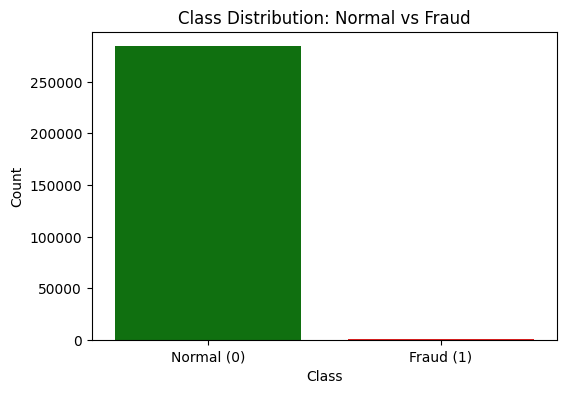

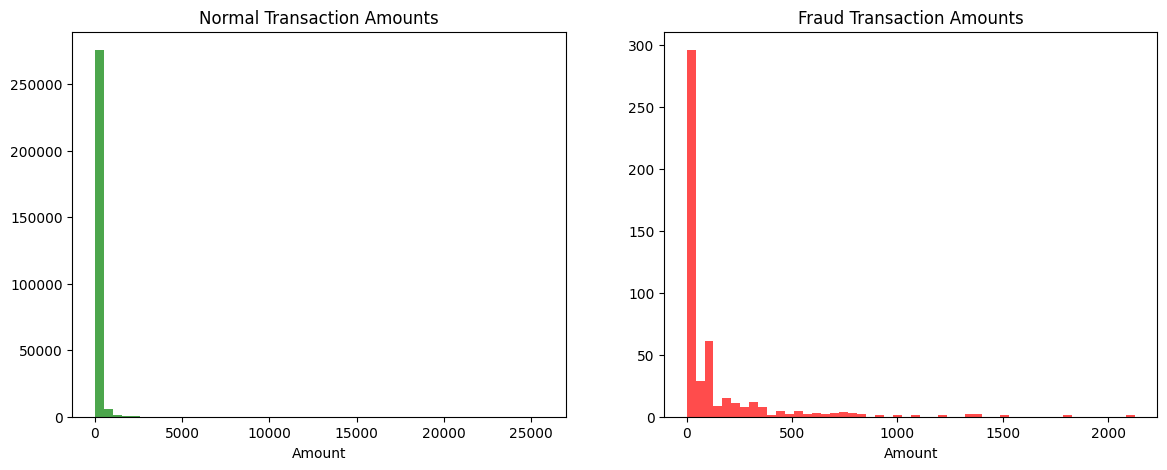

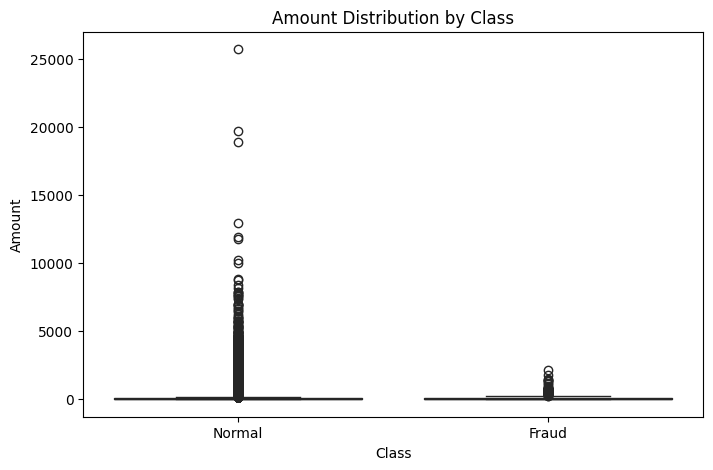

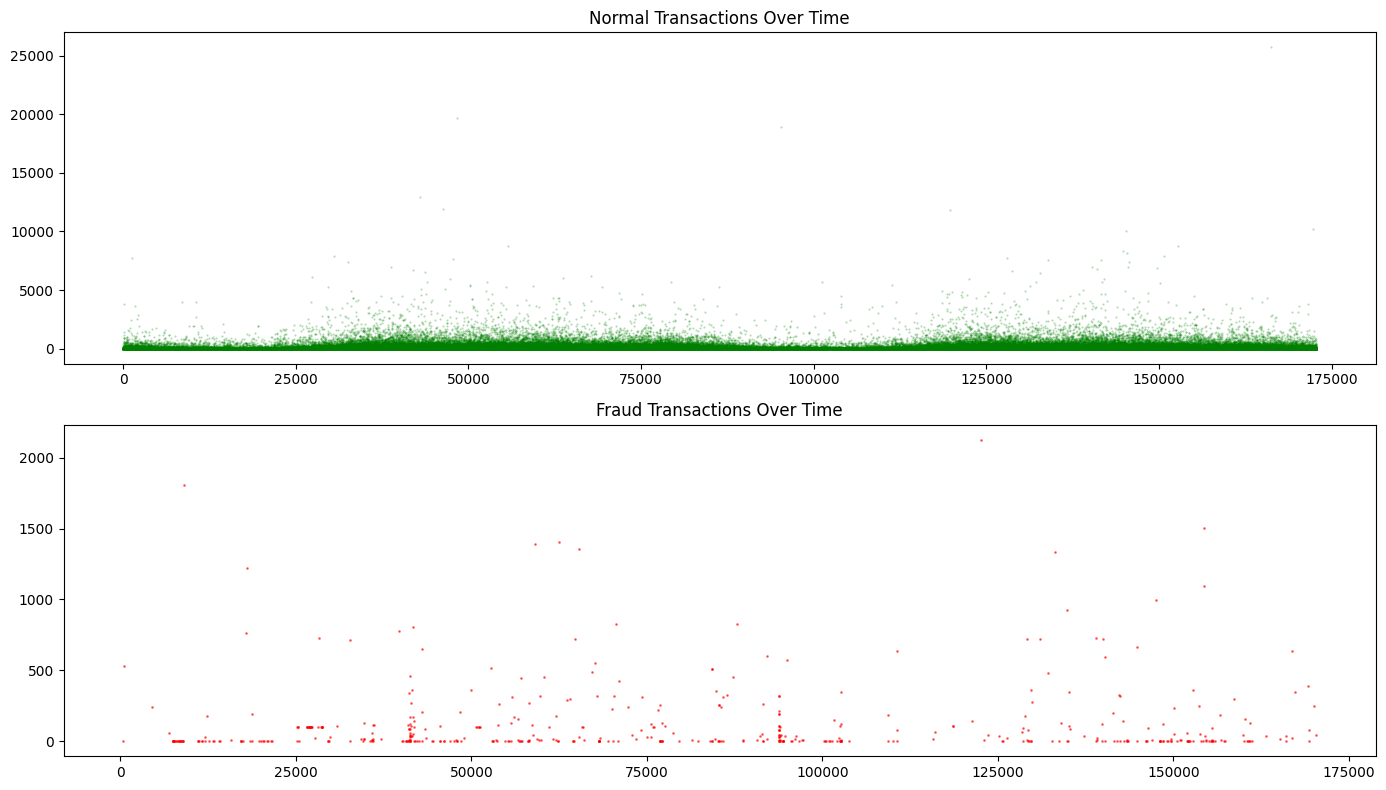

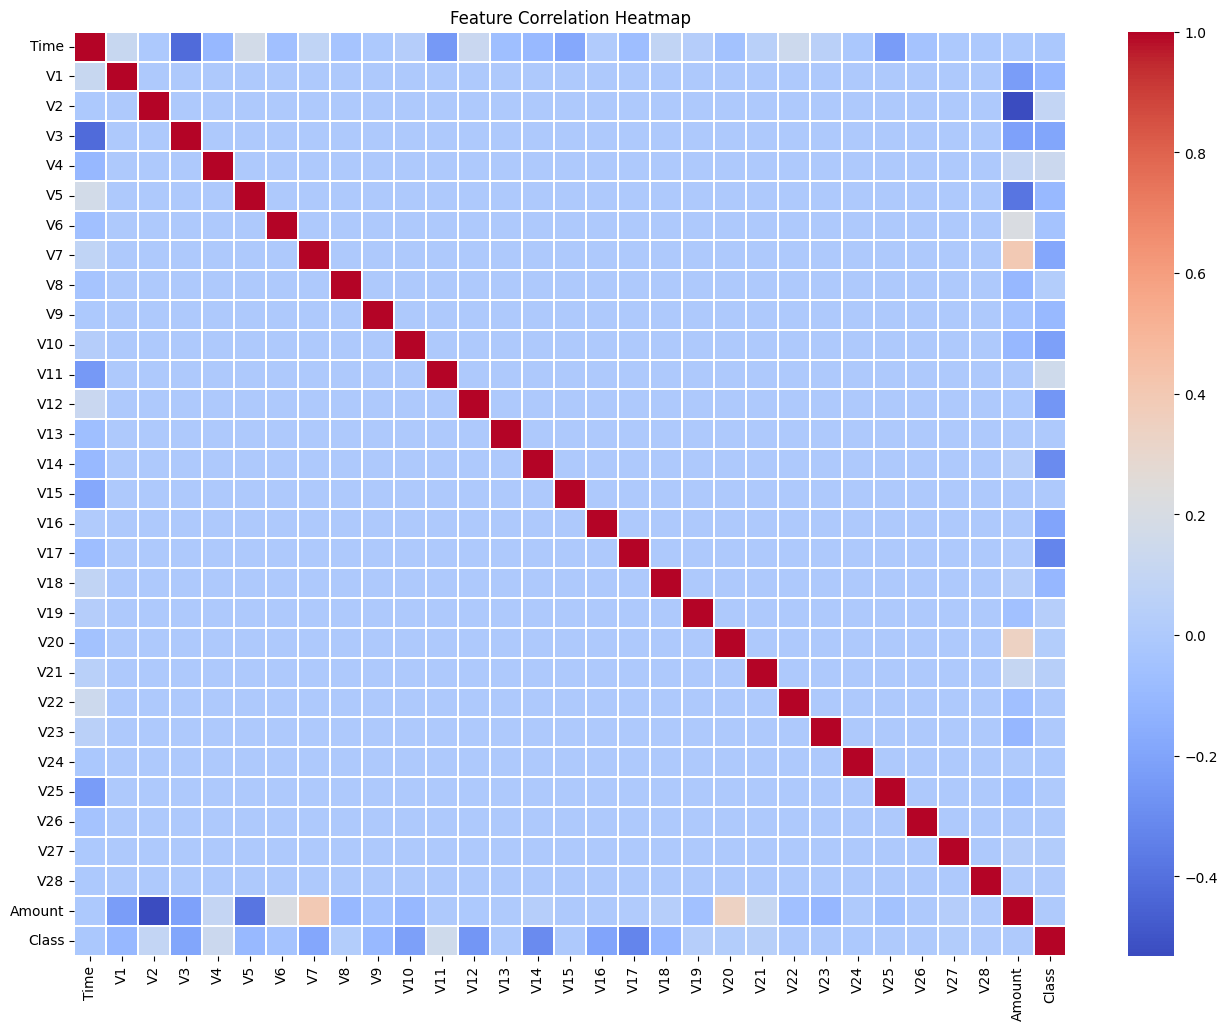

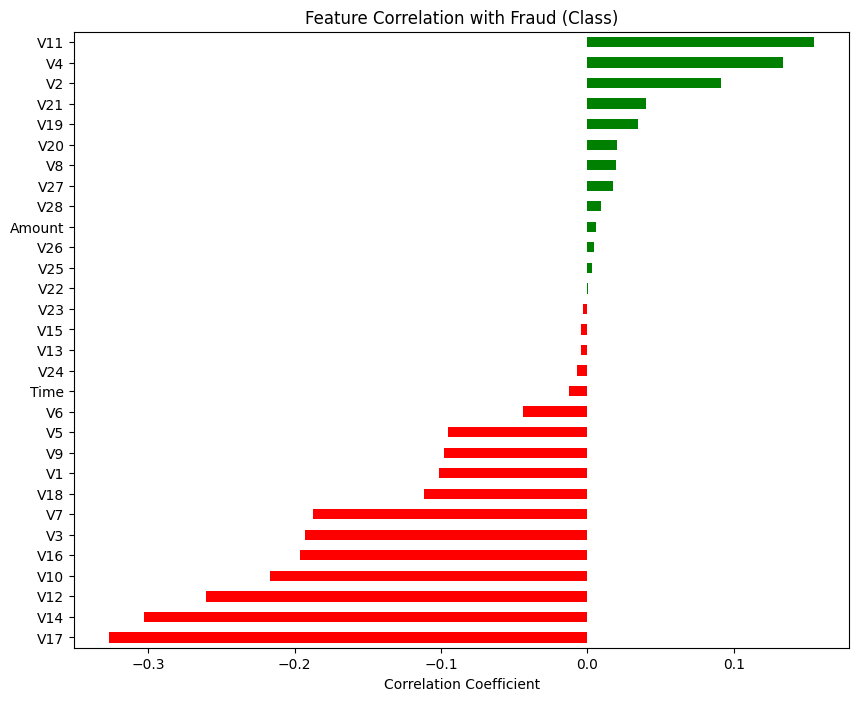

In [5]:
# PLOT 1: Class Imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['green','red'])
plt.title('Class Distribution: Normal vs Fraud')
plt.xticks([0,1], ['Normal (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()

#  PLOT 2: Transaction Amount by Class
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='green', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')
plt.savefig('plot2_amount_distribution.png', dpi=150)
plt.show()

#  PLOT 3: Transaction Amount Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df, palette=['green','red'])
plt.title('Amount Distribution by Class')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.savefig('plot3_boxplot_amount.png', dpi=150)
plt.show()

# PLOT 4: Transactions over Time
fig, axes = plt.subplots(2, 1, figsize=(14,8))
axes[0].plot(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
             '.', color='green', alpha=0.3, markersize=1)
axes[0].set_title('Normal Transactions Over Time')
axes[1].plot(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
             '.', color='red', alpha=0.5, markersize=2)
axes[1].set_title('Fraud Transactions Over Time')
plt.tight_layout()
plt.savefig('plot4_time_vs_amount.png', dpi=150)
plt.show()

#  PLOT 5: Correlation Heatmap
plt.figure(figsize=(16,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.3, annot=False)
plt.title('Feature Correlation Heatmap')
plt.savefig('plot5_correlation_heatmap.png', dpi=150)
plt.show()

# PLOT 6: Top features correlated with fraud
fraud_corr = corr['Class'].drop('Class').sort_values()
plt.figure(figsize=(10,8))
fraud_corr.plot(kind='barh', color=['red' if x < 0 else 'green' for x in fraud_corr])
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation Coefficient')
plt.savefig('plot6_fraud_correlation.png', dpi=150)
plt.show()

In [ ]:
#PREPROCESSING

In [6]:
scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['Scaled_Time'] = scaler.fit_transform(df[['Time']])

df_clean = df.drop(['Amount', 'Time'], axis=1)

print("Cleaned Dataset Shape:", df_clean.shape)
print(df_clean.head())

Cleaned Dataset Shape: (284807, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [7]:
# Separate classes
fraud = df_clean[df_clean['Class'] == 1]
normal = df_clean[df_clean['Class'] == 0]

print(f"Fraud samples: {len(fraud)}")
print(f"Normal samples: {len(normal)}")

#  METHOD 1: Undersampling
normal_under = normal.sample(n=len(fraud), random_state=42)
df_under = pd.concat([normal_under, fraud]).sample(frac=1, random_state=42)
print("\nUndersampled dataset:", df_under['Class'].value_counts())

#  METHOD 2: SMOTE Oversampling
from imblearn.over_sampling import SMOTE

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print("\nSMOTE Resampled:", pd.Series(y_smote).value_counts())

Fraud samples: 492
Normal samples: 284315

Undersampled dataset: Class
1    492
0    492
Name: count, dtype: int64

SMOTE Resampled: Class
0    284315
1    284315
Name: count, dtype: int64


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train class distribution:\n", pd.Series(y_train).value_counts())
print("Test class distribution:\n", pd.Series(y_test).value_counts())

Training set size: (454904, 30)
Testing set size: (113726, 30)
Train class distribution:
 Class
0    227452
1    227452
Name: count, dtype: int64
Test class distribution:
 Class
1    56863
0    56863
Name: count, dtype: int64


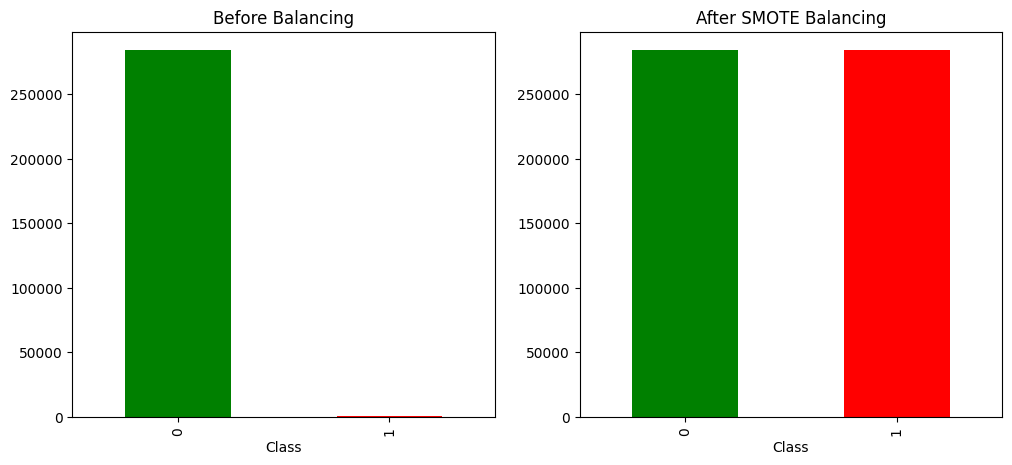

In [9]:
# Before vs After balancing
fig, axes = plt.subplots(1, 2, figsize=(12,5))
df['Class'].value_counts().plot(kind='bar', ax=axes[0],
    color=['green','red'], title='Before Balancing')
pd.Series(y_smote).value_counts().plot(kind='bar', ax=axes[1],
    color=['green','red'], title='After SMOTE Balancing')
plt.savefig('plot7_before_after_balance.png', dpi=150)
plt.show()

Training Logistic Regression...

 LOGISTIC REGRESSION RESULTS 
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95     56863
       Fraud       0.97      0.92      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC-AUC Score: 0.9895


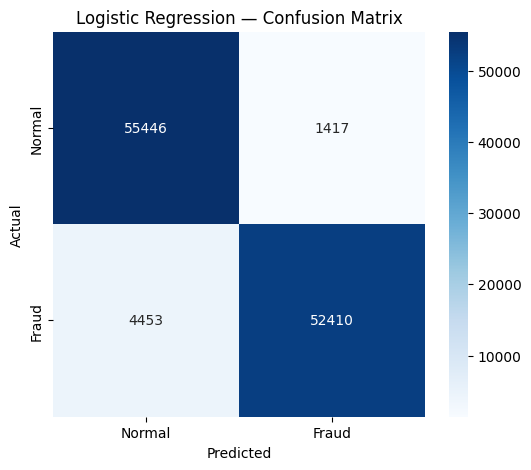

In [10]:

# MODEL 1: LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("\n LOGISTIC REGRESSION RESULTS ")
print(classification_report(y_test, lr_pred, target_names=['Normal','Fraud']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_prob), 4))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('cm_logistic.png', dpi=150)
plt.show()

Training Decision Tree

 DECISION TREE RESULTS 
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     56863
       Fraud       0.99      0.99      0.99     56863

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726

ROC-AUC Score: 0.9975


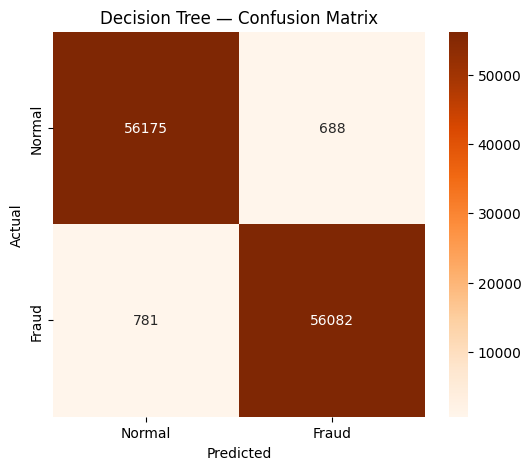

In [11]:
# MODEL 2: DECISION TREE
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree")
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

print("\n DECISION TREE RESULTS ")
print(classification_report(y_test, dt_pred, target_names=['Normal','Fraud']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, dt_prob), 4))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Decision Tree — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('cm_decision_tree.png', dpi=150)
plt.show()

Training Random Forest 

 RANDOM FOREST RESULTS 
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 1.0


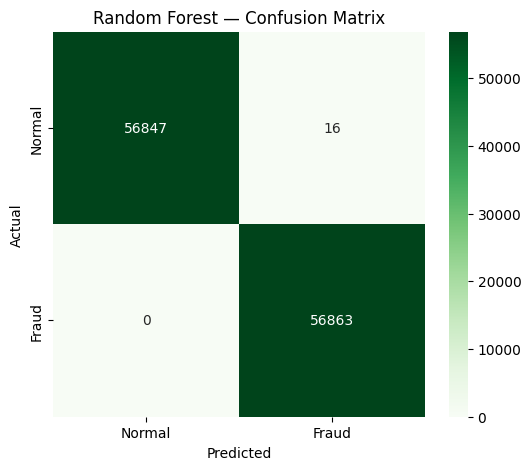

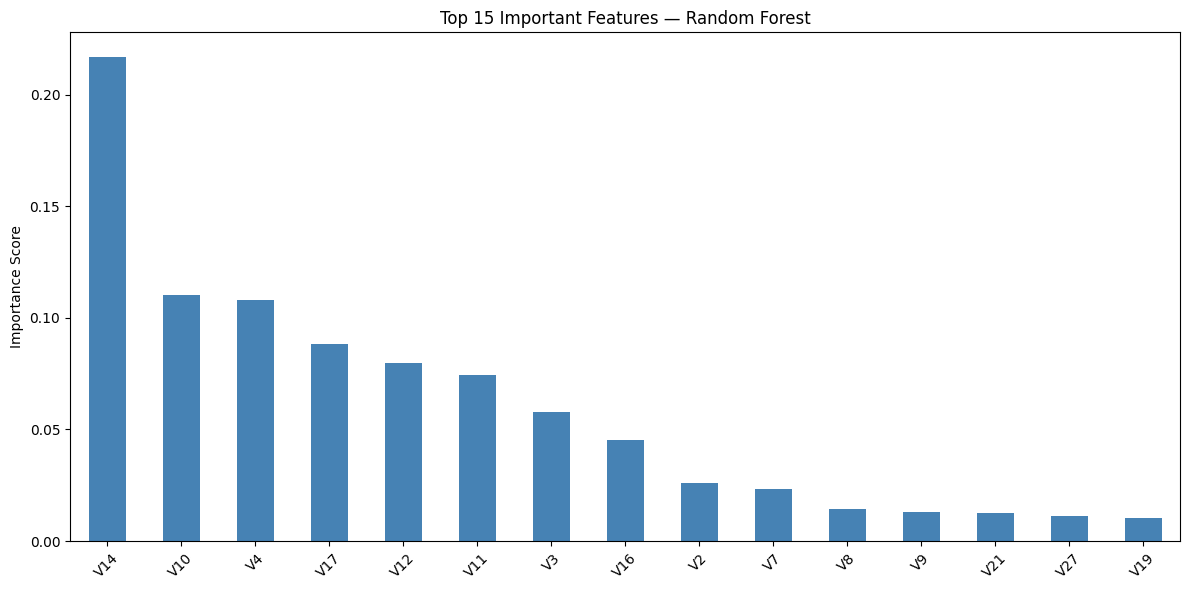

In [13]:
# MODEL 3: RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest ")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("\n RANDOM FOREST RESULTS ")
print(classification_report(y_test, rf_pred, target_names=['Normal','Fraud']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_prob), 4))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('cm_random_forest.png', dpi=150)
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12,6))
feat_imp[:15].plot(kind='bar', color='steelblue')
plt.title('Top 15 Important Features — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

Training Isolation Forest...

 ISOLATION FOREST RESULTS 
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.26      0.30      0.28       492

    accuracy                           1.00    284807
   macro avg       0.63      0.65      0.64    284807
weighted avg       1.00      1.00      1.00    284807



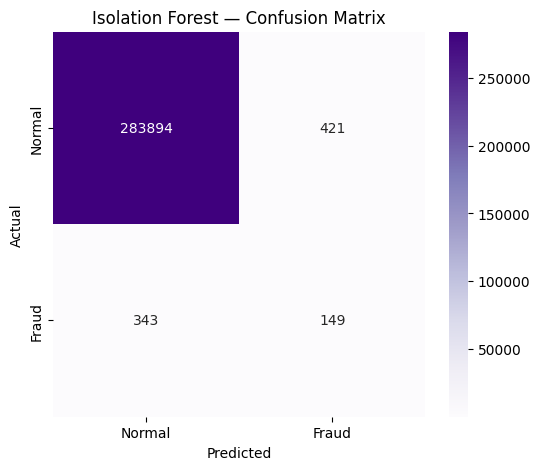

In [14]:
# MODEL 4: ISOLATION FOREST (Anomaly Detection)
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest...")

X_orig = df_clean.drop('Class', axis=1)
y_orig = df_clean['Class']

iso = IsolationForest(contamination=0.002, random_state=42, n_jobs=-1)
iso.fit(X_orig)
iso_raw = iso.predict(X_orig)

# Convert: -1 (anomaly) = Fraud(1), 1 (normal) = Normal(0)
iso_pred = [1 if x == -1 else 0 for x in iso_raw]

print("\n ISOLATION FOREST RESULTS ")
print(classification_report(y_orig, iso_pred, target_names=['Normal','Fraud']))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_orig, iso_pred),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Isolation Forest — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('cm_isolation_forest.png', dpi=150)
plt.show()

Training Local Outlier Factor 

 LOCAL OUTLIER FACTOR RESULTS (on 10K sample)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9984
       Fraud       0.40      0.50      0.44        16

    accuracy                           1.00     10000
   macro avg       0.70      0.75      0.72     10000
weighted avg       1.00      1.00      1.00     10000



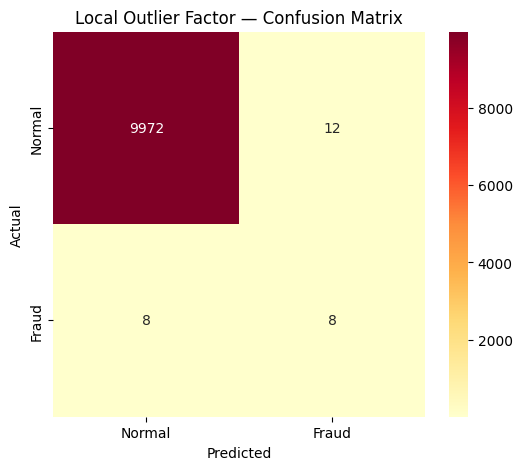

In [15]:
# MODEL 5: LOCAL OUTLIER FACTOR
from sklearn.neighbors import LocalOutlierFactor

print("Training Local Outlier Factor ")

sample_size = 10000
X_sample = X_orig.sample(n=sample_size, random_state=42)
y_sample = y_orig[X_sample.index]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.002)
lof_raw = lof.fit_predict(X_sample)

lof_pred = [1 if x == -1 else 0 for x in lof_raw]

print("\n LOCAL OUTLIER FACTOR RESULTS (on 10K sample)")
print(classification_report(y_sample, lof_pred, target_names=['Normal','Fraud']))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_sample, lof_pred),
            annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Local Outlier Factor — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('cm_lof.png', dpi=150)
plt.show()

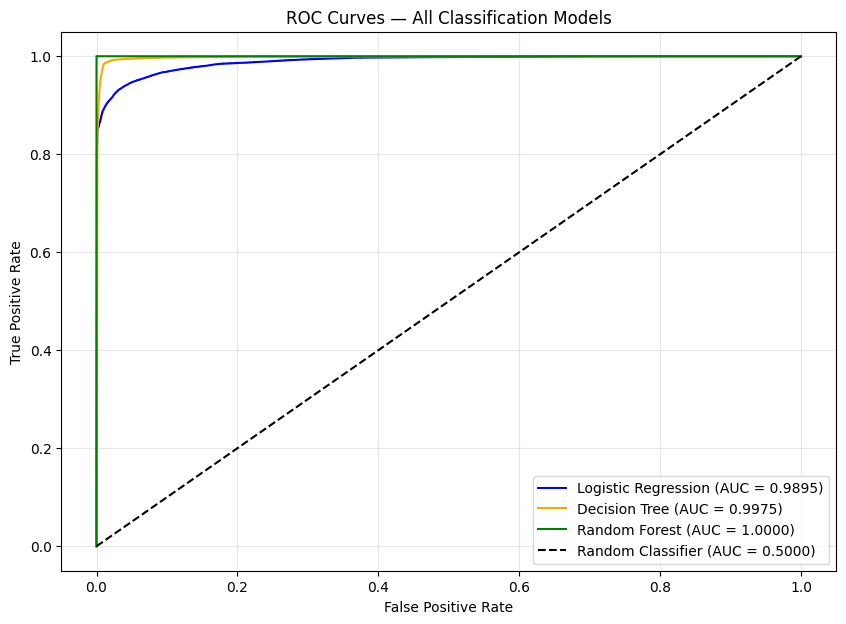

In [16]:

plt.figure(figsize=(10,7))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.4f})', color='blue')

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.4f})', color='orange')

# Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})', color='green')

# Random baseline
plt.plot([0,1], [0,1], 'k--', label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classification Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('plot_roc_curves.png', dpi=150)
plt.show()


=== FINAL MODEL COMPARISON ===
               Model  Accuracy  Precision  Recall  F1-Score
 Logistic Regression    0.9484     0.9737  0.9217    0.9470
       Decision Tree    0.9871     0.9879  0.9863    0.9871
       Random Forest    0.9999     0.9997  1.0000    0.9999
    Isolation Forest    0.9973     0.2614  0.3028    0.2806
Local Outlier Factor    0.9980     0.4000  0.5000    0.4444


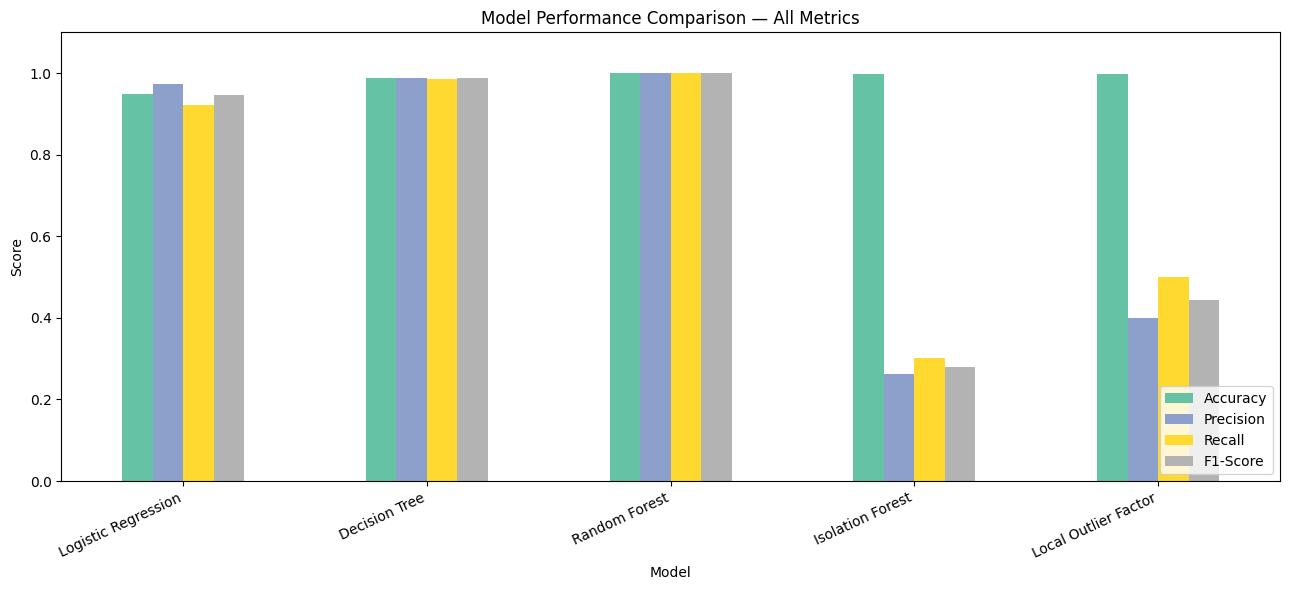

In [17]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree',
              'Random Forest', 'Isolation Forest', 'Local Outlier Factor'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_orig, iso_pred),
        accuracy_score(y_sample, lof_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_orig, iso_pred),
        precision_score(y_sample, lof_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_orig, iso_pred),
        recall_score(y_sample, lof_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_orig, iso_pred),
        f1_score(y_sample, lof_pred)
    ]
}

results_df = pd.DataFrame(results)
print("\n=== FINAL MODEL COMPARISON ===")
print(results_df.round(4).to_string(index=False))

# Bar chart comparison
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]\
    .plot(kind='bar', figsize=(13,6), colormap='Set2')
plt.title('Model Performance Comparison — All Metrics')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150)
plt.show()

In [18]:
# BEST MODEL IDENTIFICATION
best_f1_idx = results_df['F1-Score'].idxmax()
best_model  = results_df.loc[best_f1_idx, 'Model']
best_f1     = results_df.loc[best_f1_idx, 'F1-Score']
best_recall = results_df.loc[best_f1_idx, 'Recall']

print("BEST PERFORMING MODEL:", best_model)
print(f"F1-Score  : {best_f1:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_prob):.4f}")

print("""
CONCLUSION:
- Random Forest achieved the highest overall performance
- Recall is the most critical metric in fraud detection
  (missing a fraud is worse than a false alarm)
- SMOTE effectively handled class imbalance
- Final model is suitable for integration into banking systems
""")

BEST PERFORMING MODEL: Random Forest
F1-Score  : 0.9999
Recall    : 1.0000
ROC-AUC   : 1.0000

CONCLUSION:
- Random Forest achieved the highest overall performance
- Recall is the most critical metric in fraud detection
  (missing a fraud is worse than a false alarm)
- SMOTE effectively handled class imbalance
- Final model is suitable for integration into banking systems

